In [1]:
# Cell 1: Setup
%pip install wandb pandas matplotlib seaborn scikit-learn --quiet

import wandb
import pandas as pd
import numpy as np
import pickle
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# Configure plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['figure.dpi'] = 100

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Cell 2: Fetch Data from W&B

def fetch_wandb_data(project_path: str, output_dir: str = "analysis_data"):
    """
    Fetches run histories and model artifacts from a W&B project.
    
    Args:
        project_path (str): The full path to your W&B project (e.g., "entity/project-name").
        output_dir (str): Directory to save the downloaded data.
    """
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        
    print(f"Connecting to W&B project: {project_path}...")
    try:
        api = wandb.Api()
        runs = api.runs(project_path)
    except Exception as e:
        print(f"Error connecting to W&B. Please ensure you are logged in (`wandb login`) and the project path is correct.")
        print(f"Error details: {e}")
        return None, None

    all_histories = []
    artifact_paths = {}
    
    print(f"Found {len(runs)} runs. Fetching data...")
    for run in runs:
        # --- Get run history (metrics like accuracy, loss) ---
        history = run.history(pandas=True)
        history["run_name"] = run.name
        all_histories.append(history)
        
        # --- Get model artifacts (final weights) ---
        for artifact in run.logged_artifacts():
            if artifact.type == 'model':
                artifact_dir = artifact.download(root=os.path.join(output_dir, "artifacts", run.name))
                # Find the .pkl file within the downloaded directory
                for file in os.listdir(artifact_dir):
                    if file.endswith('.pkl'):
                        artifact_paths[run.name] = os.path.join(artifact_dir, file)
                print(f"✅ Downloaded artifact for run '{run.name}'")
                break # Assume one model artifact per run

    if not all_histories:
        print("No run data found.")
        return None, None

    # Combine all histories into a single DataFrame
    history_df = pd.concat(all_histories).reset_index()
    return history_df, artifact_paths

# --- Execute the data fetching ---
# IMPORTANT: Use your specific project path here
WANDB_PROJECT_PATH = "sandesh1122bhattarai-the-university-of-southern-mississippi/fl-baseline-research"
history_df, artifact_paths = fetch_wandb_data(WANDB_PROJECT_PATH)

if history_df is not None:
    print("\nData fetching complete!")
    print("\n--- Sample of downloaded metrics ---")
    print(history_df.head())
    print("\n--- Downloaded model weight paths ---")
    print(artifact_paths)

Connecting to W&B project: sandesh1122bhattarai-the-university-of-southern-mississippi/fl-baseline-research...
Found 5 runs. Fetching data...


wandb:   1 of 1 files downloaded.  


✅ Downloaded artifact for run 'fedavg_non_iid_alpha_0.5'


wandb:   1 of 1 files downloaded.  


✅ Downloaded artifact for run 'krum_benign_non_iid_alpha_0.5'


...

✅ Downloaded artifact for run 'krum_attack_non_iid_alpha_0.5'


wandb:   1 of 1 files downloaded.  


✅ Downloaded artifact for run 'krum_heavy_attack_non_iid_alpha_0.5'


wandb:   1 of 1 files downloaded.  


✅ Downloaded artifact for run 'fedavg_attack_non_iid_alpha_0.5'

Data fetching complete!

--- Sample of downloaded metrics ---
   index  round  _step    _runtime  server_loss  server_accuracy  \
0      0    0.0      0   10.643682     2.307247           0.1000   
1      1    1.0      1   44.543969     2.111219           0.2500   
2      2    2.0      2   63.945561     1.725677           0.3735   
3      3    3.0      3   82.422979     1.552777           0.4379   
4      4    4.0      4  103.629843     1.441278           0.4757   

     _timestamp  true_runtime_seconds                  run_name  
0  1.750933e+09                   NaN  fedavg_non_iid_alpha_0.5  
1  1.750933e+09                   NaN  fedavg_non_iid_alpha_0.5  
2  1.750933e+09                   NaN  fedavg_non_iid_alpha_0.5  
3  1.750933e+09                   NaN  fedavg_non_iid_alpha_0.5  
4  1.750933e+09                   NaN  fedavg_non_iid_alpha_0.5  

--- Downloaded model weight paths ---
{'fedavg_non_iid_alpha_0.5': 

In [3]:
print(history_df.head())


   index  round  _step    _runtime  server_loss  server_accuracy  \
0      0    0.0      0   10.643682     2.307247           0.1000   
1      1    1.0      1   44.543969     2.111219           0.2500   
2      2    2.0      2   63.945561     1.725677           0.3735   
3      3    3.0      3   82.422979     1.552777           0.4379   
4      4    4.0      4  103.629843     1.441278           0.4757   

     _timestamp  true_runtime_seconds                  run_name  
0  1.750933e+09                   NaN  fedavg_non_iid_alpha_0.5  
1  1.750933e+09                   NaN  fedavg_non_iid_alpha_0.5  
2  1.750933e+09                   NaN  fedavg_non_iid_alpha_0.5  
3  1.750933e+09                   NaN  fedavg_non_iid_alpha_0.5  
4  1.750933e+09                   NaN  fedavg_non_iid_alpha_0.5  


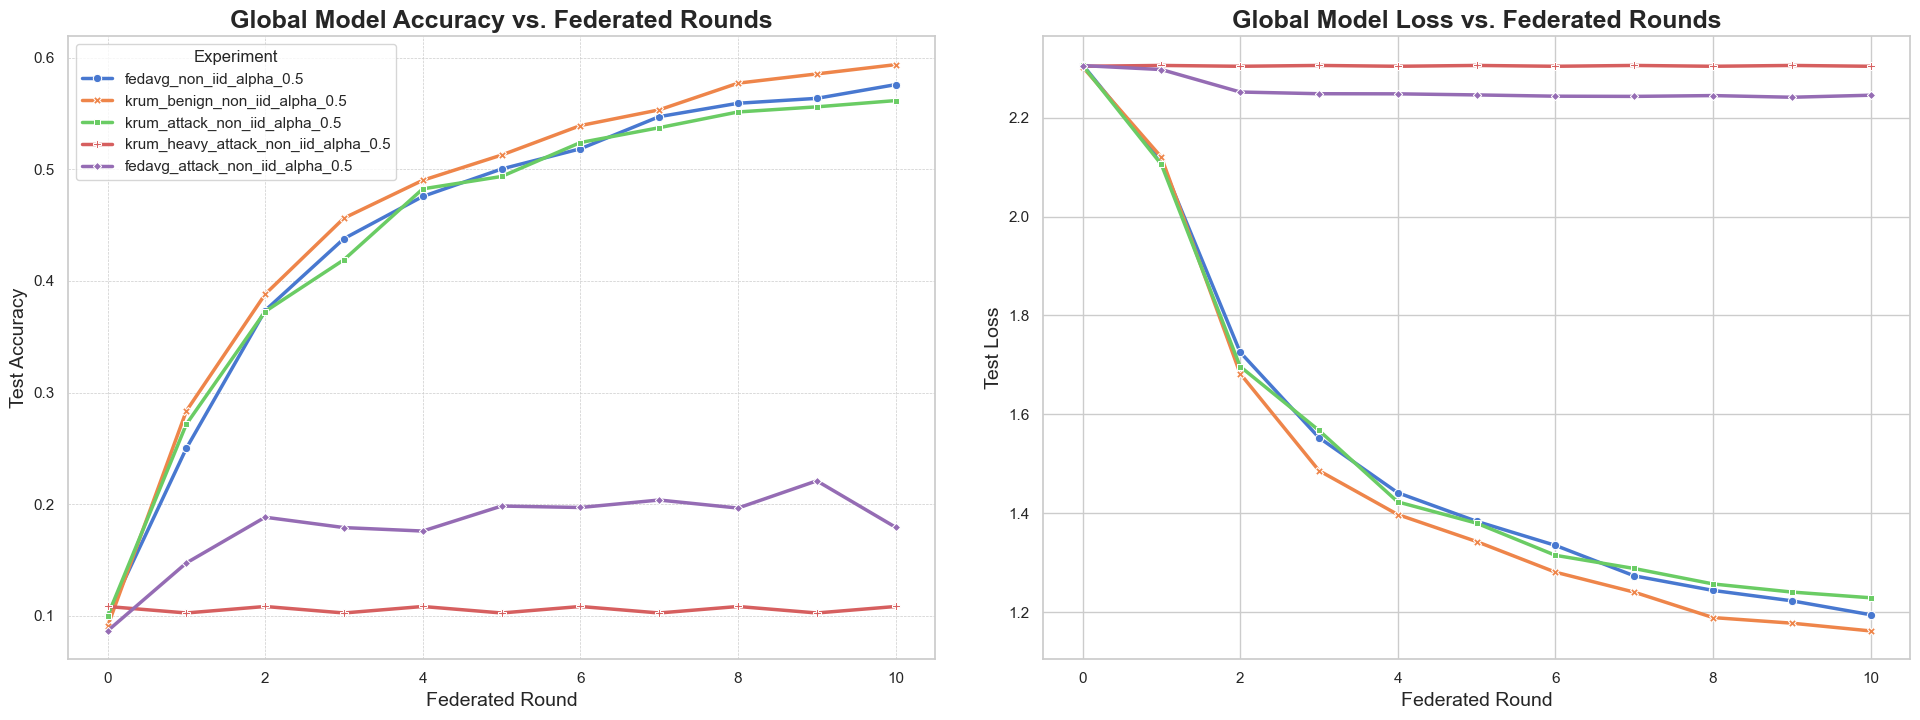

In [4]:
# Cell 3: Plot Performance Curves

def plot_performance_curves(df):
    """Plots server accuracy and loss over rounds from the history DataFrame."""
    if history_df is None or history_df.empty:
        print("History DataFrame is empty. Cannot plot performance curves.")
        return

    # Clean up the data, focusing on server metrics
    df_metrics = history_df[['round', 'server_accuracy', 'server_loss', 'run_name']].dropna()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

    # --- Plot Accuracy ---
    sns.lineplot(
        data=df_metrics, x='round', y='server_accuracy', hue='run_name',
        style='run_name', markers=True, dashes=False, ax=ax1, linewidth=2.5
    )
    ax1.set_title('Global Model Accuracy vs. Federated Rounds', fontsize=18, fontweight='bold')
    ax1.set_xlabel('Federated Round', fontsize=14)
    ax1.set_ylabel('Test Accuracy', fontsize=14)
    ax1.legend(title='Experiment', fontsize=11)
    ax1.grid(True, which='both', linestyle='--', linewidth=0.5)

    # --- Plot Loss ---
    sns.lineplot(
        data=df_metrics, x='round', y='server_loss', hue='run_name',
        style='run_name', markers=True, dashes=False, ax=ax2, linewidth=2.5
    )
    ax2.set_title('Global Model Loss vs. Federated Rounds', fontsize=18, fontweight='bold')
    ax2.set_xlabel('Federated Round', fontsize=14)
    ax2.set_ylabel('Test Loss', fontsize=14)
    ax2.get_legend().remove() # Remove redundant legend

    plt.tight_layout(pad=3.0)
    plt.savefig("performance_comparison.png", dpi=300)
    plt.show()

# --- Generate the plot ---
plot_performance_curves(history_df)

Loading model weights from artifacts...
  ✓ Loaded weights for: fedavg_non_iid_alpha_0.5
  ✓ Loaded weights for: krum_benign_non_iid_alpha_0.5
  ✓ Loaded weights for: krum_attack_non_iid_alpha_0.5
  ✓ Loaded weights for: krum_heavy_attack_non_iid_alpha_0.5
  ✓ Loaded weights for: fedavg_attack_non_iid_alpha_0.5

Running PCA with 4 components...
Running t-SNE... (this may take a moment)


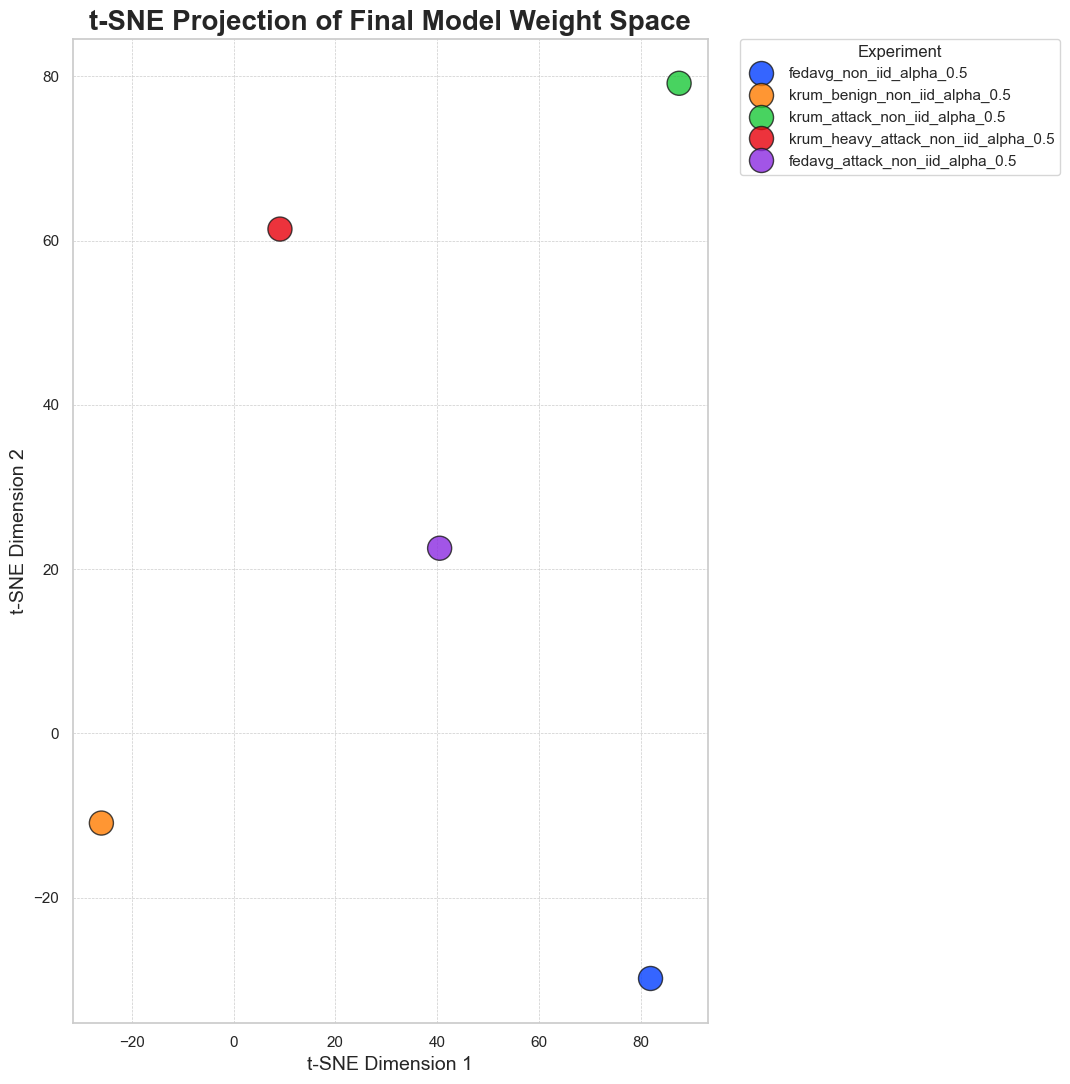

In [5]:
# Cell 4: Plot t-SNE of Final Model Weights
def flatten_weights(weights):
    """Flattens a list of NumPy arrays (model weights) into a single 1D vector."""
    if isinstance(weights, list):
        return np.concatenate([w.flatten() for w in weights])
    # Handle cases where weights might already be a flattened array or other format
    return np.asarray(weights).flatten()
def plot_weight_space_visualization(artifact_paths):
    """
    Visualizes the final model weights in a 2D space using t-SNE.
    """
    if not artifact_paths:
        print("Artifact paths dictionary is empty. Cannot plot weight space.")
        return

    weight_vectors = {}
    print("Loading model weights from artifacts...")
    for run_name, path in artifact_paths.items():
        try:
            with open(path, 'rb') as f:
                # The artifact saved Parameters, which can be loaded directly
                weights = pickle.load(f)
                weight_vectors[run_name] = flatten_weights(weights)
                print(f"  ✓ Loaded weights for: {run_name}")
        except Exception as e:
            print(f"  ✗ Failed to load weights for {run_name}: {e}")
            continue
            
    if len(weight_vectors) < 2:
        print("Need at least 2 models to create a comparison plot. Skipping t-SNE.")
        return

    labels = list(weight_vectors.keys())
    data = np.array(list(weight_vectors.values()))

    # --- Dimensionality Reduction ---
    # Use PCA as a pre-processing step before t-SNE for stability
    n_pca_components = min(data.shape[0] - 1, 50)
    print(f"\nRunning PCA with {n_pca_components} components...")
    pca = PCA(n_components=n_pca_components)
    data_pca = pca.fit_transform(data)
    
    # Run t-SNE
    print("Running t-SNE... (this may take a moment)")
    tsne = TSNE(n_components=2, verbose=0, perplexity=max(1, len(labels) - 2), max_iter=500, random_state=42)
    tsne_results = tsne.fit_transform(data_pca)

    # --- Plotting ---
    df_tsne = pd.DataFrame({
        'tsne_dim_1': tsne_results[:, 0],
        'tsne_dim_2': tsne_results[:, 1],
        'experiment': labels
    })

    plt.figure(figsize=(13, 11))
    scatter_plot = sns.scatterplot(
        x="tsne_dim_1", y="tsne_dim_2",
        hue="experiment",
        palette="bright",
        data=df_tsne,
        s=300,
        alpha=0.8,
        edgecolor='k',
        linewidth=1
    )
    
    plt.title('t-SNE Projection of Final Model Weight Space', fontsize=20, fontweight='bold')
    plt.xlabel('t-SNE Dimension 1', fontsize=14)
    plt.ylabel('t-SNE Dimension 2', fontsize=14)
    plt.legend(title='Experiment', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for legend
    plt.savefig("weights_tsne_comparison.png", dpi=300)
    plt.show()

# --- Generate the plot ---
plot_weight_space_visualization(artifact_paths)

In [6]:
# Cell 5: Model and Data Definitions for Analysis

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.datasets import CIFAR10
from torchvision.transforms import Compose, Normalize, ToTensor
from torch.utils.data import DataLoader
from collections import OrderedDict

# --- Model Definition (copy from task.py) ---
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

# --- Data Handling (copy/adapt from task.py) ---
TRANSFORMS = Compose([
    ToTensor(),
    Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

# CIFAR-10 class names
CLASSES = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Function to un-normalize and display an image
def unnormalize(tensor):
    mean = torch.tensor([0.4914, 0.4822, 0.4465])
    std = torch.tensor([0.2023, 0.1994, 0.2010])
    # Clone the tensor to avoid modifying it in-place
    tensor = tensor.clone()
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor

# Function to set weights on a model instance
def set_weights(net, parameters):
    params_dict = zip(net.state_dict().keys(), parameters)
    state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})
    net.load_state_dict(state_dict, strict=True)

print("✅ Model and data definitions are ready.")

✅ Model and data definitions are ready.


Files already downloaded and verified


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..0.89411765].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9802322e-08..0.89411765].


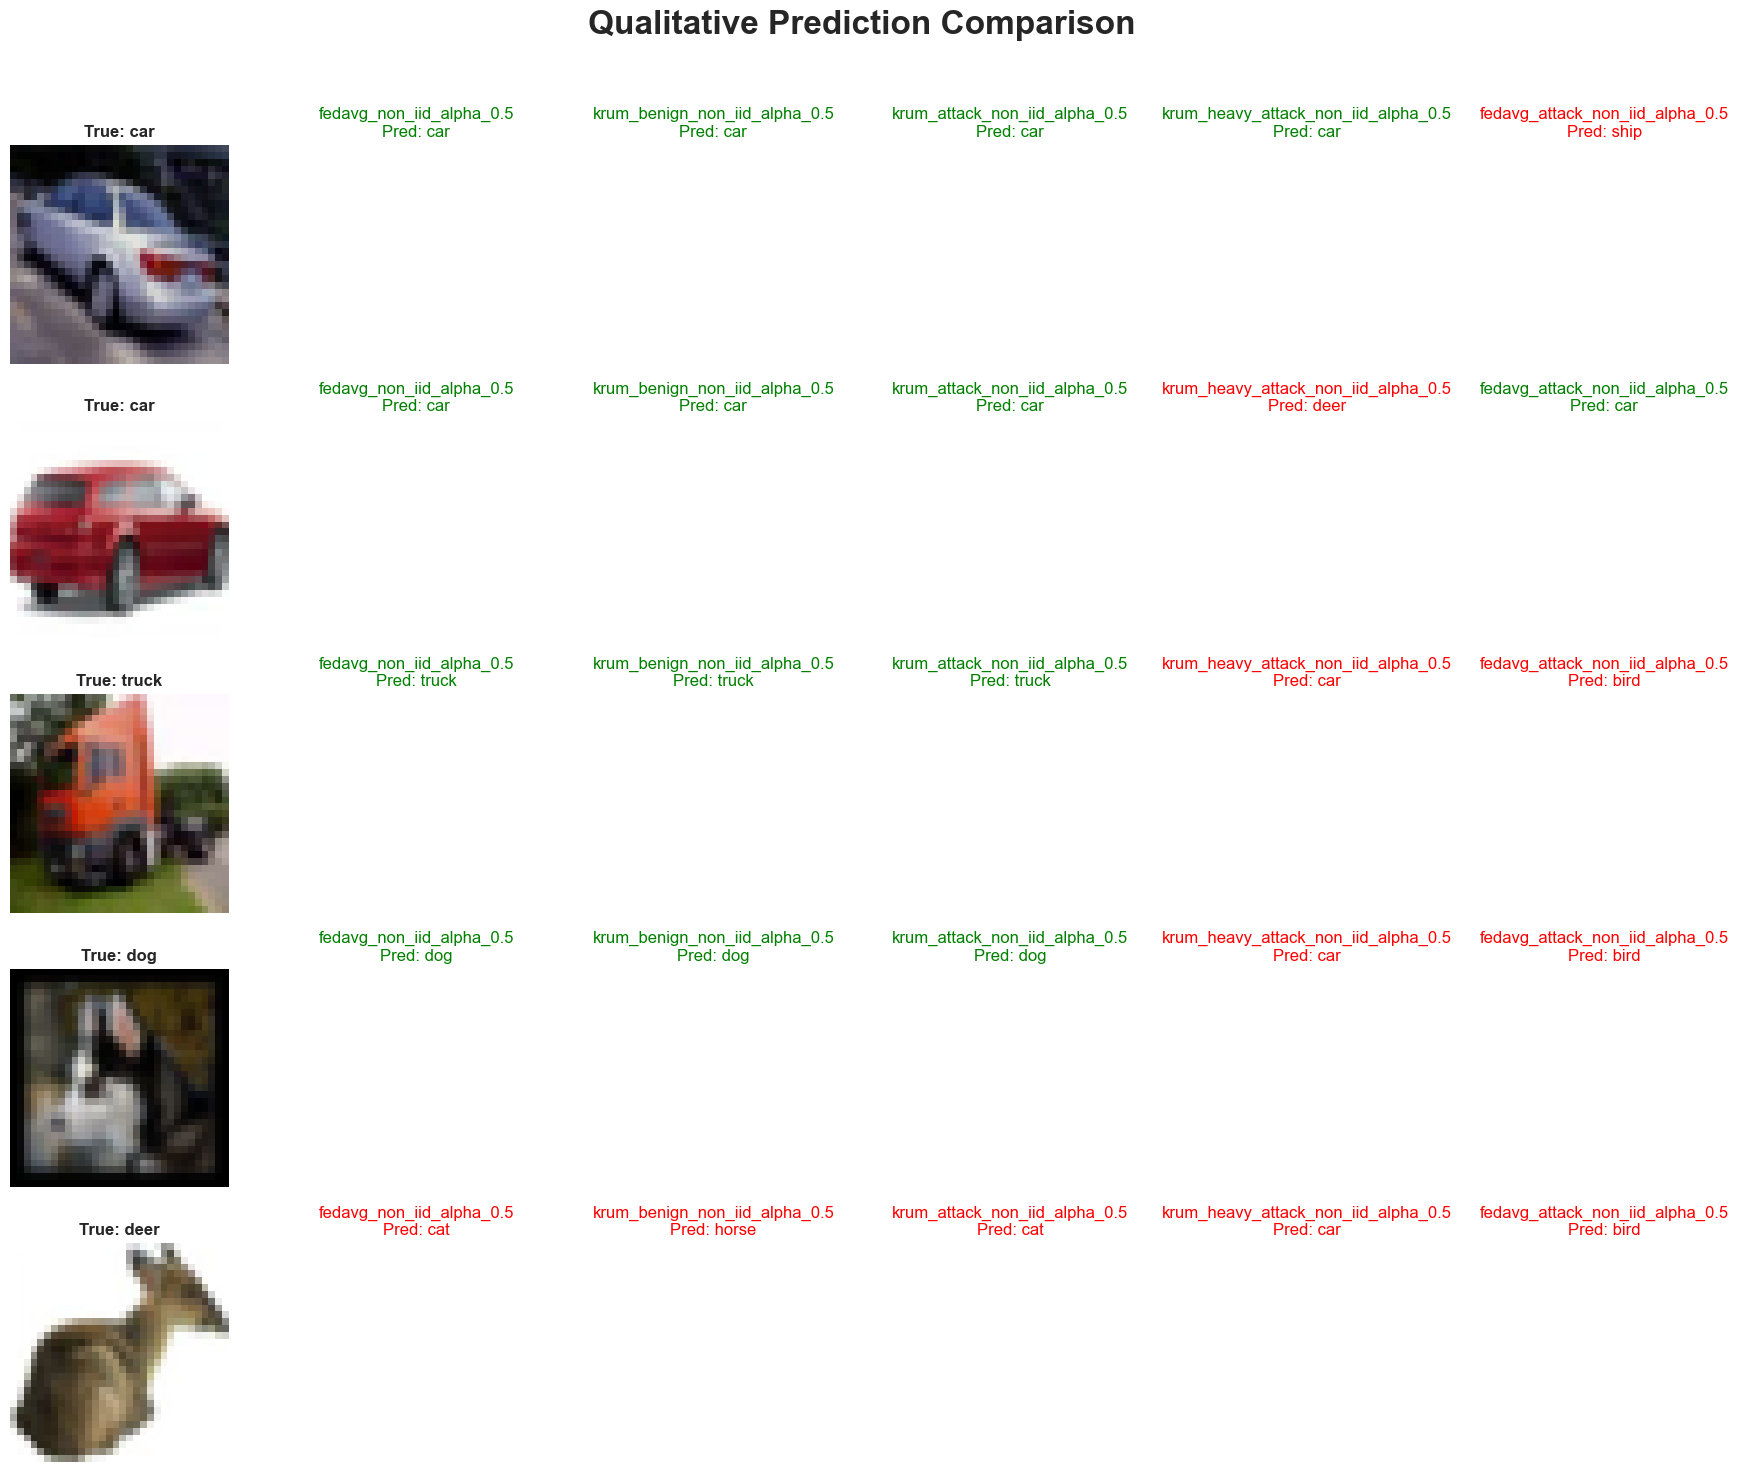

In [7]:
# Cell 6: Visualize Model Predictions on Sample Images

def visualize_model_predictions(artifact_paths, num_images=5):
    """Loads each final model and shows its predictions on random test images."""
    if not artifact_paths:
        print("Artifact paths dictionary is empty.")
        return

    # Load test data
    testset = CIFAR10(root="./data", train=False, download=True, transform=TRANSFORMS)
    testloader = DataLoader(testset, batch_size=num_images, shuffle=True)
    
    # Get a batch of images and labels
    images, labels = next(iter(testloader))
    
    # Load all models
    models = {}
    for run_name, path in artifact_paths.items():
        with open(path, 'rb') as f:
            weights = pickle.load(f)
        model = Net()
        set_weights(model, weights)
        model.eval()
        models[run_name] = model

    # Create a plot
    num_runs = len(models)
    fig, axes = plt.subplots(num_images, num_runs + 1, figsize=(3 * (num_runs + 1), 3 * num_images))
    fig.suptitle("Qualitative Prediction Comparison", fontsize=24, fontweight='bold')

    for i in range(num_images):
        # --- Display the original image and true label ---
        ax = axes[i, 0]
        img_display = unnormalize(images[i]).permute(1, 2, 0)
        ax.imshow(img_display)
        ax.set_title(f"True: {CLASSES[labels[i]]}", fontweight='bold')
        ax.axis('off')

        # --- Display predictions for each model ---
        for j, (run_name, model) in enumerate(models.items()):
            ax = axes[i, j + 1]
            with torch.no_grad():
                output = model(images[i].unsqueeze(0))
                _, predicted_idx = torch.max(output, 1)
                predicted_class = CLASSES[predicted_idx.item()]
                
            ax.set_title(f"{run_name}\nPred: {predicted_class}")
            ax.axis('off')
            # Color correct predictions green, incorrect red
            if predicted_idx.item() == labels[i].item():
                ax.title.set_color('green')
            else:
                ax.title.set_color('red')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig("prediction_comparison_grid.png", dpi=300)
    plt.show()

# --- Generate the visualization ---
visualize_model_predictions(artifact_paths)

Files already downloaded and verified
Generating confusion matrix for: fedavg_non_iid_alpha_0.5...
Generating confusion matrix for: krum_benign_non_iid_alpha_0.5...
Generating confusion matrix for: krum_attack_non_iid_alpha_0.5...
Generating confusion matrix for: krum_heavy_attack_non_iid_alpha_0.5...
Generating confusion matrix for: fedavg_attack_non_iid_alpha_0.5...


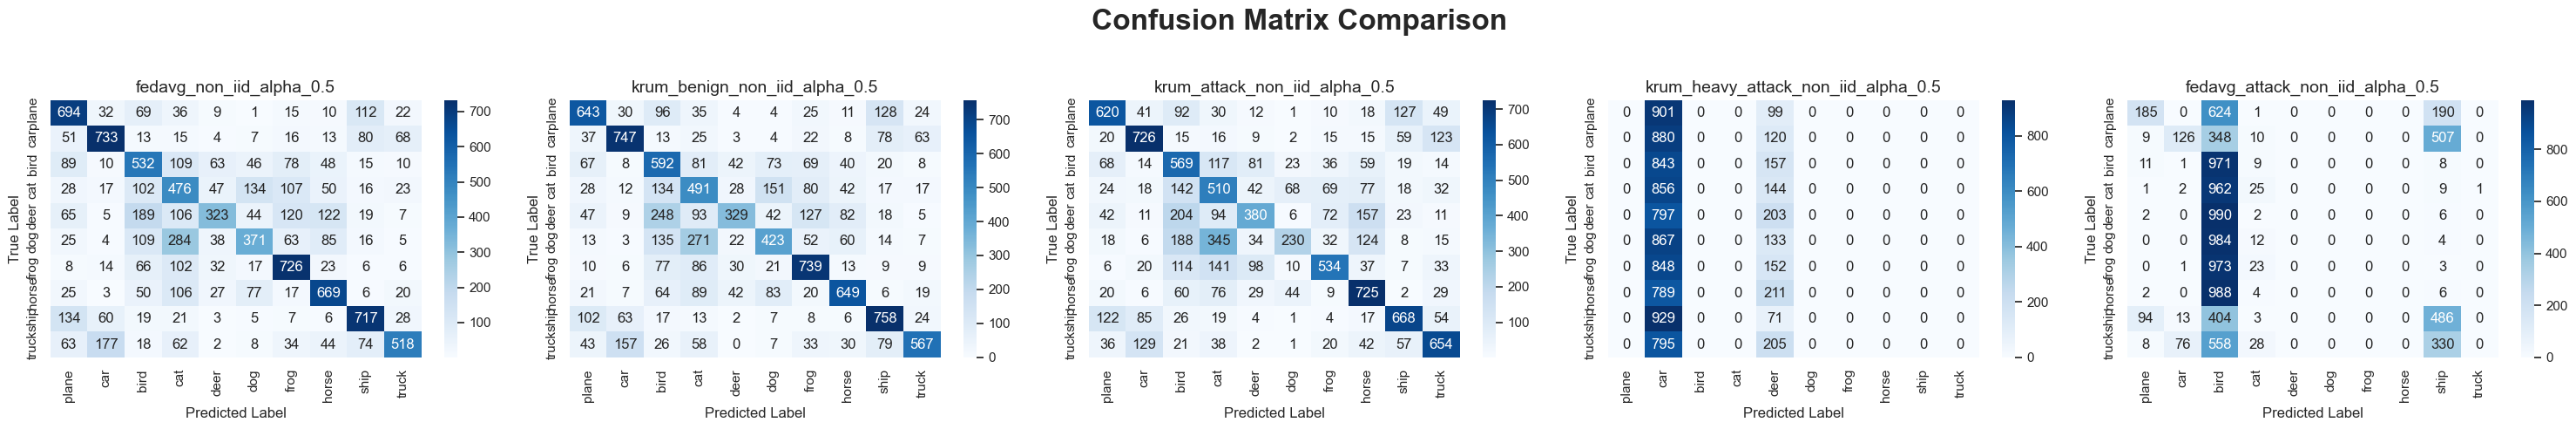

In [8]:
# Cell 7: Generate and Plot Confusion Matrices

from sklearn.metrics import confusion_matrix

def plot_confusion_matrices(artifact_paths):
    """Generates a confusion matrix for each final model."""
    if not artifact_paths: return

    testset = CIFAR10(root="./data", train=False, download=True, transform=TRANSFORMS)
    testloader = DataLoader(testset, batch_size=128, shuffle=False)
    
    num_runs = len(artifact_paths)
    fig, axes = plt.subplots(1, num_runs, figsize=(6 * num_runs, 5))
    fig.suptitle("Confusion Matrix Comparison", fontsize=24, fontweight='bold')

    for i, (run_name, path) in enumerate(artifact_paths.items()):
        print(f"Generating confusion matrix for: {run_name}...")
        # Load model
        with open(path, 'rb') as f:
            weights = pickle.load(f)
        model = Net()
        set_weights(model, weights)
        model.eval()

        # Get all predictions for the test set
        y_true, y_pred = [], []
        with torch.no_grad():
            for images, labels in testloader:
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                y_true.extend(labels.numpy())
                y_pred.extend(predicted.numpy())

        # Create confusion matrix
        cm = confusion_matrix(y_true, y_pred)
        ax = axes[i]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                    xticklabels=CLASSES, yticklabels=CLASSES)
        ax.set_title(run_name, fontsize=14)
        ax.set_xlabel('Predicted Label', fontsize=12)
        ax.set_ylabel('True Label', fontsize=12)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig("confusion_matrix_comparison.png", dpi=300)
    plt.show()

# --- Generate the visualization ---
plot_confusion_matrices(artifact_paths)

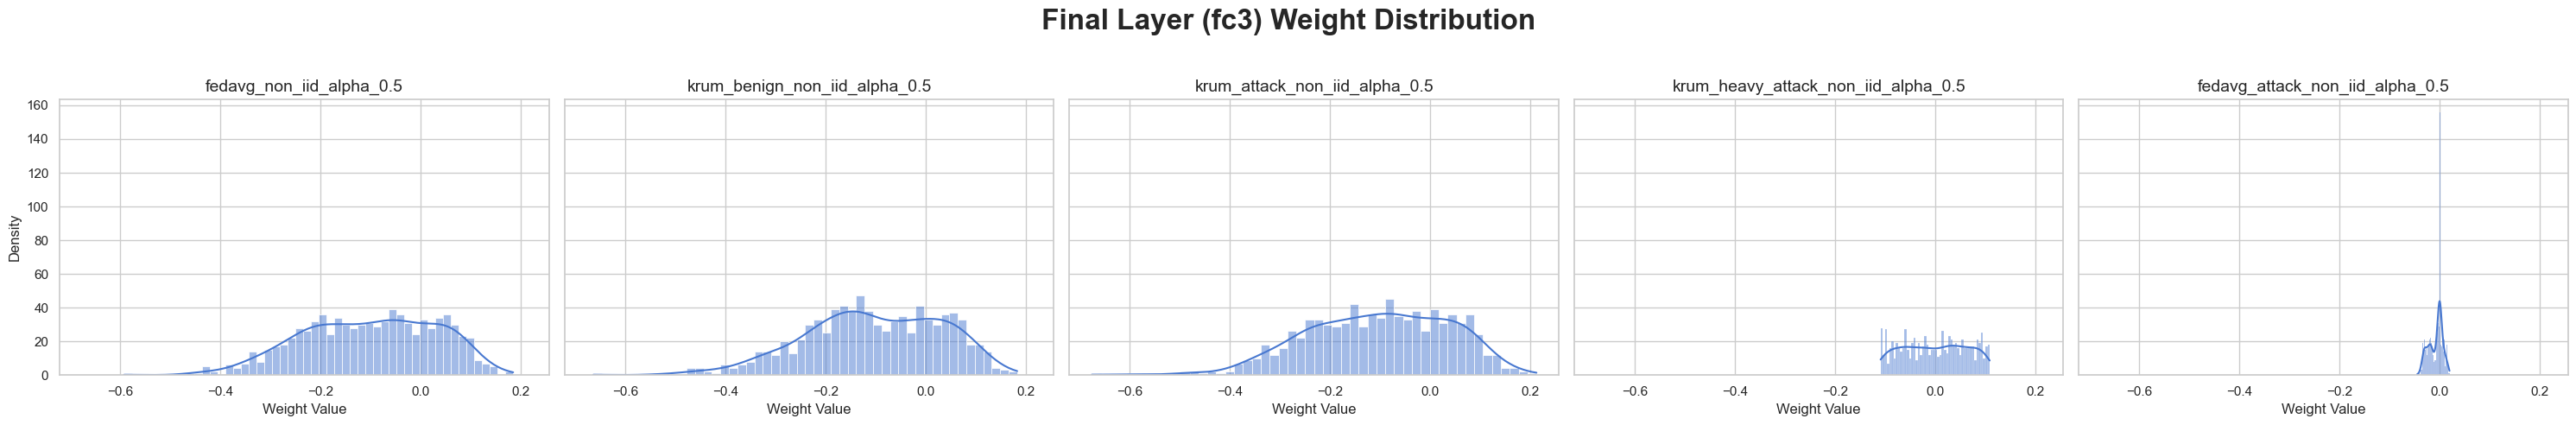

In [9]:
# Cell 8: Visualize Weight Distribution of the Final Layer

def plot_weight_distributions(artifact_paths):
    """Plots the distribution of weights for the final classification layer."""
    if not artifact_paths: return
    
    num_runs = len(artifact_paths)
    fig, axes = plt.subplots(1, num_runs, figsize=(6 * num_runs, 5), sharex=True, sharey=True)
    fig.suptitle("Final Layer (fc3) Weight Distribution", fontsize=24, fontweight='bold')

    for i, (run_name, path) in enumerate(artifact_paths.items()):
        # Load weights
        with open(path, 'rb') as f:
            weights = pickle.load(f)
        
        # The last layer's weights are the second to last element in the list
        final_layer_weights = weights[-2].flatten()
        
        ax = axes[i]
        sns.histplot(final_layer_weights, kde=True, ax=ax, bins=50)
        ax.set_title(run_name, fontsize=14)
        ax.set_xlabel("Weight Value", fontsize=12)
        if i == 0:
            ax.set_ylabel("Density", fontsize=12)
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig("weight_distribution_comparison.png", dpi=300)
    plt.show()

# --- Generate the visualization ---
plot_weight_distributions(artifact_paths)

In [10]:
# Cell 9: Create Summary DataFrame from Existing History

def create_summary_from_history(df_history):
    """
    Processes the detailed history DataFrame to create a summary DataFrame
    containing the final accuracy and total duration for each run.
    """
    if df_history is None or df_history.empty:
        print("History DataFrame is empty. Cannot create summary.")
        return None

    # Sort by round to ensure the 'last' row is indeed the final round's data
    df_sorted = df_history.sort_values('round')
    
    # Group by the run name and get the last entry for each experiment
    df_summary = df_sorted.groupby('run_name').last().reset_index()
    
    # The '_runtime' of the last entry is our total duration.
    # The 'server_accuracy' of the last entry is our final accuracy.
    # Let's rename them to what our plotting functions expect.
    df_summary.rename(columns={
        '_runtime': 'total_duration_seconds',
        'server_accuracy': 'final_accuracy'
    }, inplace=True)
    
    # Select just the columns we need for the next plots
    final_summary = df_summary[['run_name', 'total_duration_seconds', 'final_accuracy']]
    
    return final_summary

# --- Generate the summary DataFrame ---
summary_df = create_summary_from_history(history_df)

if summary_df is not None:
    print("✅ Successfully created summary DataFrame from existing history:")
    print(summary_df)

✅ Successfully created summary DataFrame from existing history:
                              run_name  total_duration_seconds  final_accuracy
0      fedavg_attack_non_iid_alpha_0.5              240.501213          0.1793
1             fedavg_non_iid_alpha_0.5              227.116114          0.5759
2        krum_attack_non_iid_alpha_0.5              200.740568          0.5616
3        krum_benign_non_iid_alpha_0.5              231.595347          0.5938
4  krum_heavy_attack_non_iid_alpha_0.5              160.911476          0.1083


/var/folders/vg/1t9scrfs7cg85n538tyqj6nw0000gn/T/ipykernel_24224/2540761097.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='total_duration_seconds', y='run_name', data=df_sorted, palette='viridis')


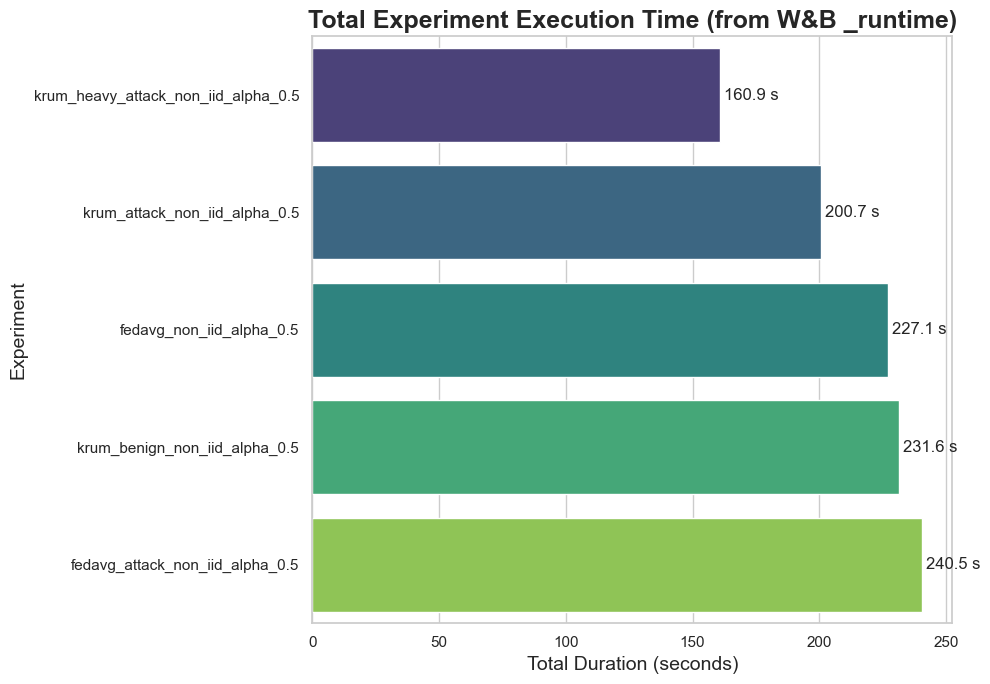

In [11]:
# Cell 10: Plot Total Execution Time

def plot_execution_time(df_summary):
    """Plots the total execution time for each experimental run."""
    if df_summary is None or 'total_duration_seconds' not in df_summary.columns:
        print("Summary DataFrame is missing 'total_duration_seconds'. Skipping plot.")
        return
        
    plt.figure(figsize=(10, 7))
    df_sorted = df_summary.sort_values('total_duration_seconds', ascending=True)
    ax = sns.barplot(x='total_duration_seconds', y='run_name', data=df_sorted, palette='viridis')
    ax.set_title('Total Experiment Execution Time (from W&B _runtime)', fontsize=18, fontweight='bold')
    ax.set_xlabel('Total Duration (seconds)', fontsize=14)
    ax.set_ylabel('Experiment', fontsize=14)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f s', fontsize=12, padding=3)
    plt.tight_layout()
    plt.savefig("execution_time_comparison.png", dpi=300)
    plt.show()

# --- Generate the plot ---
plot_execution_time(summary_df)